# How Many Clusters? Evaluating K in K-Means Using the Elbow Method and Silhouette Score

**Author:** ISRAEL AJAYI IYANUOLUWA  
**Course:** Machine Learning and Neural Networks  
**GitHub:** [https://github.com/Easywiz/K-Means-Elbow-vs-Silhouette]

---

## Overview
One of the biggest challenges in K-Means clustering is choosing the right number of clusters **K**. Choose too few and you miss meaningful structure in your data. Choose too many and your clusters become arbitrary and uninterpretable.

In this tutorial, we explore **two principled methods** for evaluating K:
1. **The Elbow Method** — based on inertia
2. **The Silhouette Score** — based on cluster cohesion and separation

We use two datasets:
- A **synthetic dataset** (where we know the true K) to show the methods working perfectly
- The **Wine Quality dataset** (UCI) to show how methods behave on real-world data

---

## References
- Arthur, D. and Vassilvitskii, S. (2007) 'k-means++: The advantages of careful seeding', SODA '07, pp. 1027–1035.
- Rousseeuw, P.J. (1987) 'Silhouettes...', Journal of Computational and Applied Mathematics, 20, pp. 53–65.
- Thorndike, R.L. (1953) 'Who belongs in the family?', Psychometrika, 18(4), pp. 267–276.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', JMLR, 12, pp. 2825–2830.
- UCI Machine Learning Repository (no date) Wine Dataset. Available at: https://archive.ics.uci.edu/ml/datasets/wine
- Scikit-learn developers (2024) Clustering. Available at: https://scikit-learn.org/stable/modules/clustering.html

## 1. Setup and Imports

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# ── Accessibility: Use colourblind-friendly palette throughout ────────────────
# Using the 'tab10' palette which is perceptually distinct
PALETTE = sns.color_palette('colorblind')
sns.set_palette('colorblind')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

RANDOM_STATE = 42  # For reproducibility
print('All packages loaded successfully.')

All packages loaded successfully.


---
## 2. A Quick Recap: How K-Means Works

K-Means partitions N data points into K clusters by minimising **inertia** — the sum of squared distances from each point to its assigned centroid:

$$\text{Inertia} = \sum_{i=1}^{N} \min_{k} \| x_i - \mu_k \|^2$$

The algorithm:
1. **Initialise** K centroids (randomly, or via K-Means++)
2. **Assign** each point to the nearest centroid
3. **Update** centroids to the mean of assigned points
4. **Repeat** steps 2–3 until convergence

The key problem: **K must be chosen before running the algorithm.**

---
## 3. Part A — Synthetic Dataset (Known Ground Truth)

We first create a dataset where we **know** the true number of clusters is 4. This lets us verify that our evaluation methods find the right answer.

[Figure 1 Alt Text]: Two scatter plots side by side. Left shows unlabelled data points. Right shows the same data coloured by true cluster membership, revealing 4 distinct groups.


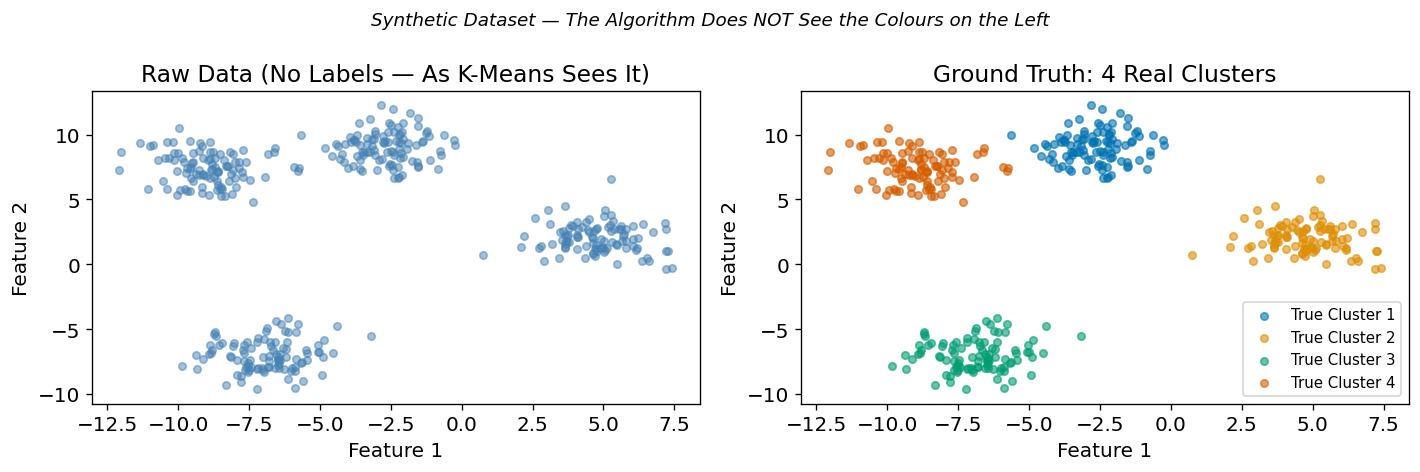

In [2]:
# ── Generate synthetic data with 4 true clusters ──────────────────────────────
TRUE_K = 4

X_syn, y_true = make_blobs(
    n_samples=400,
    centers=TRUE_K,
    cluster_std=1.2,
    random_state=RANDOM_STATE
)

# Visualise the raw data (without labels — as K-Means sees it)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# What the algorithm sees
axes[0].scatter(X_syn[:, 0], X_syn[:, 1], alpha=0.5, color='steelblue', s=20)
axes[0].set_title('Raw Data (No Labels — As K-Means Sees It)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Ground truth
for k in range(TRUE_K):
    mask = y_true == k
    axes[1].scatter(X_syn[mask, 0], X_syn[mask, 1],
                    label=f'True Cluster {k+1}', alpha=0.6, s=20)
axes[1].set_title(f'Ground Truth: {TRUE_K} Real Clusters')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend(loc='best', fontsize=9)

plt.suptitle('Synthetic Dataset — The Algorithm Does NOT See the Colours on the Left',
             fontsize=11, style='italic')
plt.tight_layout()

# Alt text for accessibility
print('[Figure 1 Alt Text]: Two scatter plots side by side. Left shows unlabelled data points.'
      ' Right shows the same data coloured by true cluster membership, revealing 4 distinct groups.')
plt.savefig('fig1_synthetic_data.png', bbox_inches='tight')
plt.show()

---
## 4. The Elbow Method

**Inertia always decreases as K increases** — with K=N, every point is its own cluster and inertia = 0. So we cannot just minimise inertia.

The Elbow Method looks for the point where inertia stops decreasing sharply — the **"elbow"** — suggesting that adding more clusters gives diminishing returns.

[Figure 2 Alt Text]: Line plot of inertia vs K from 1 to 12. The curve drops steeply then flattens after K=4, forming a visible elbow at K=4.


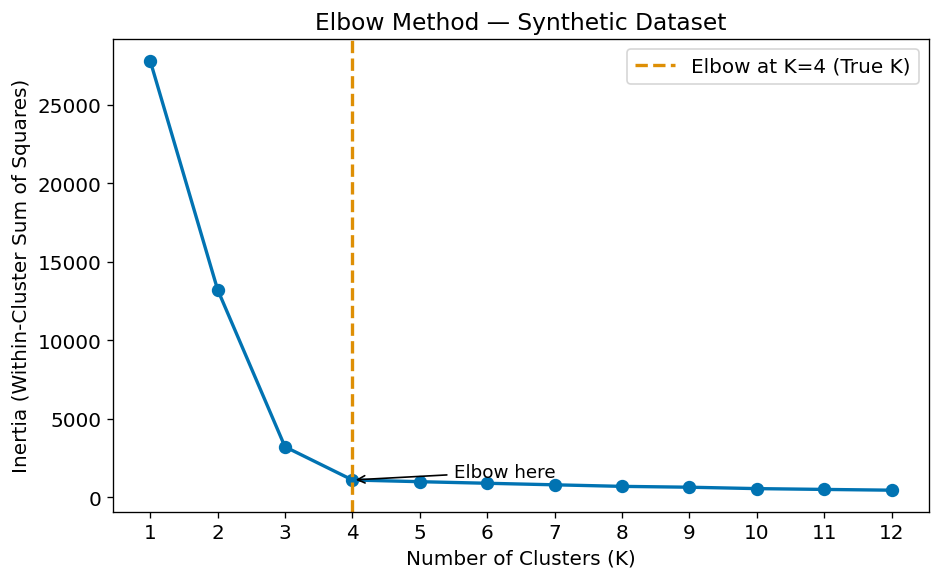


Inertia values:
  K= 1 → Inertia = 27811.18
  K= 2 → Inertia = 13234.29
  K= 3 → Inertia = 3218.66
  K= 4 → Inertia = 1103.79
  K= 5 → Inertia = 995.40
  K= 6 → Inertia = 894.92
  K= 7 → Inertia = 796.80
  K= 8 → Inertia = 697.33
  K= 9 → Inertia = 643.49
  K=10 → Inertia = 554.35
  K=11 → Inertia = 502.84
  K=12 → Inertia = 454.03


In [3]:
# ── Compute inertia for K = 1 to 12 ──────────────────────────────────────────
K_range = range(1, 13)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_syn)
    inertias.append(km.inertia_)

# ── Plot the Elbow Curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=7)

# Highlight the elbow
ax.axvline(x=TRUE_K, color=PALETTE[1], linestyle='--', linewidth=2,
           label=f'Elbow at K={TRUE_K} (True K)')
ax.annotate('Elbow here', xy=(TRUE_K, inertias[TRUE_K-1]),
            xytext=(TRUE_K+1.5, inertias[TRUE_K-1]+200),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11)

ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method — Synthetic Dataset')
ax.legend()
ax.set_xticks(list(K_range))

print('[Figure 2 Alt Text]: Line plot of inertia vs K from 1 to 12. The curve drops steeply'
      ' then flattens after K=4, forming a visible elbow at K=4.')
plt.savefig('fig2_elbow_synthetic.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'\nInertia values:')
for k, inertia in zip(K_range, inertias):
    print(f'  K={k:2d} → Inertia = {inertia:.2f}')

---
## 5. The Silhouette Score

The Silhouette Score measures **how well each point fits its own cluster compared to neighbouring clusters**.

For each point $i$:
- $a(i)$ = mean distance to all other points **in the same cluster** (cohesion)
- $b(i)$ = mean distance to all points **in the nearest other cluster** (separation)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

| Score | Meaning |
|-------|--------|
| Close to **+1** | Point is well-matched to its cluster |
| Close to **0** | Point is on the boundary between clusters |
| Close to **-1** | Point may be in the wrong cluster |

Best K by Silhouette Score: K=4 (Score=0.7519)
[Figure 3 Alt Text]: Line plot of silhouette score vs K from 2 to 12. Score peaks at K=4 confirming the true cluster count.


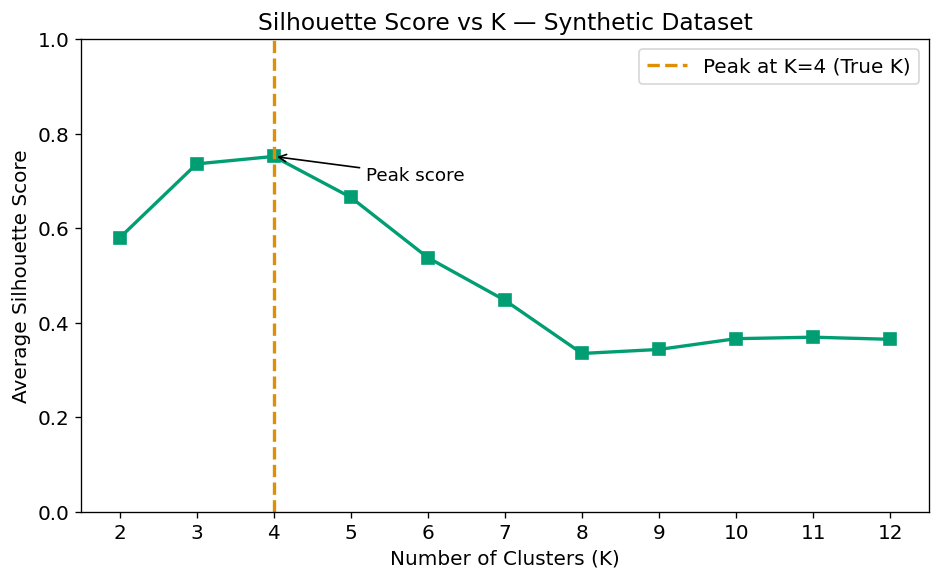

In [4]:
# ── Compute Silhouette Scores for K = 2 to 12 ─────────────────────────────────
# Note: Silhouette score is undefined for K=1
K_range_sil = range(2, 13)
sil_scores = []

for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_syn)
    score = silhouette_score(X_syn, labels)
    sil_scores.append(score)

# ── Plot Average Silhouette Score ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_range_sil), sil_scores, 's-', color=PALETTE[2], linewidth=2, markersize=7)
ax.axvline(x=TRUE_K, color=PALETTE[1], linestyle='--', linewidth=2,
           label=f'Peak at K={TRUE_K} (True K)')
ax.annotate('Peak score', xy=(TRUE_K, max(sil_scores)),
            xytext=(TRUE_K+1.2, max(sil_scores)-0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11)

ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Average Silhouette Score')
ax.set_title('Silhouette Score vs K — Synthetic Dataset')
ax.set_xticks(list(K_range_sil))
ax.set_ylim(0, 1)
ax.legend()

best_k = list(K_range_sil)[sil_scores.index(max(sil_scores))]
print(f'Best K by Silhouette Score: K={best_k} (Score={max(sil_scores):.4f})')
print('[Figure 3 Alt Text]: Line plot of silhouette score vs K from 2 to 12.'
      ' Score peaks at K=4 confirming the true cluster count.')
plt.savefig('fig3_silhouette_scores.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

---
## 6. Silhouette Plot — Per-Cluster Breakdown

Beyond the average score, we can plot **silhouette diagrams** for each K to see how individual points score within their clusters. This reveals whether clusters are balanced and well-separated.

[Figure 4 Alt Text]: Four silhouette diagrams for K=2,3,4,5. K=4 shows the widest, most uniform bars — all clusters score well above the average line.


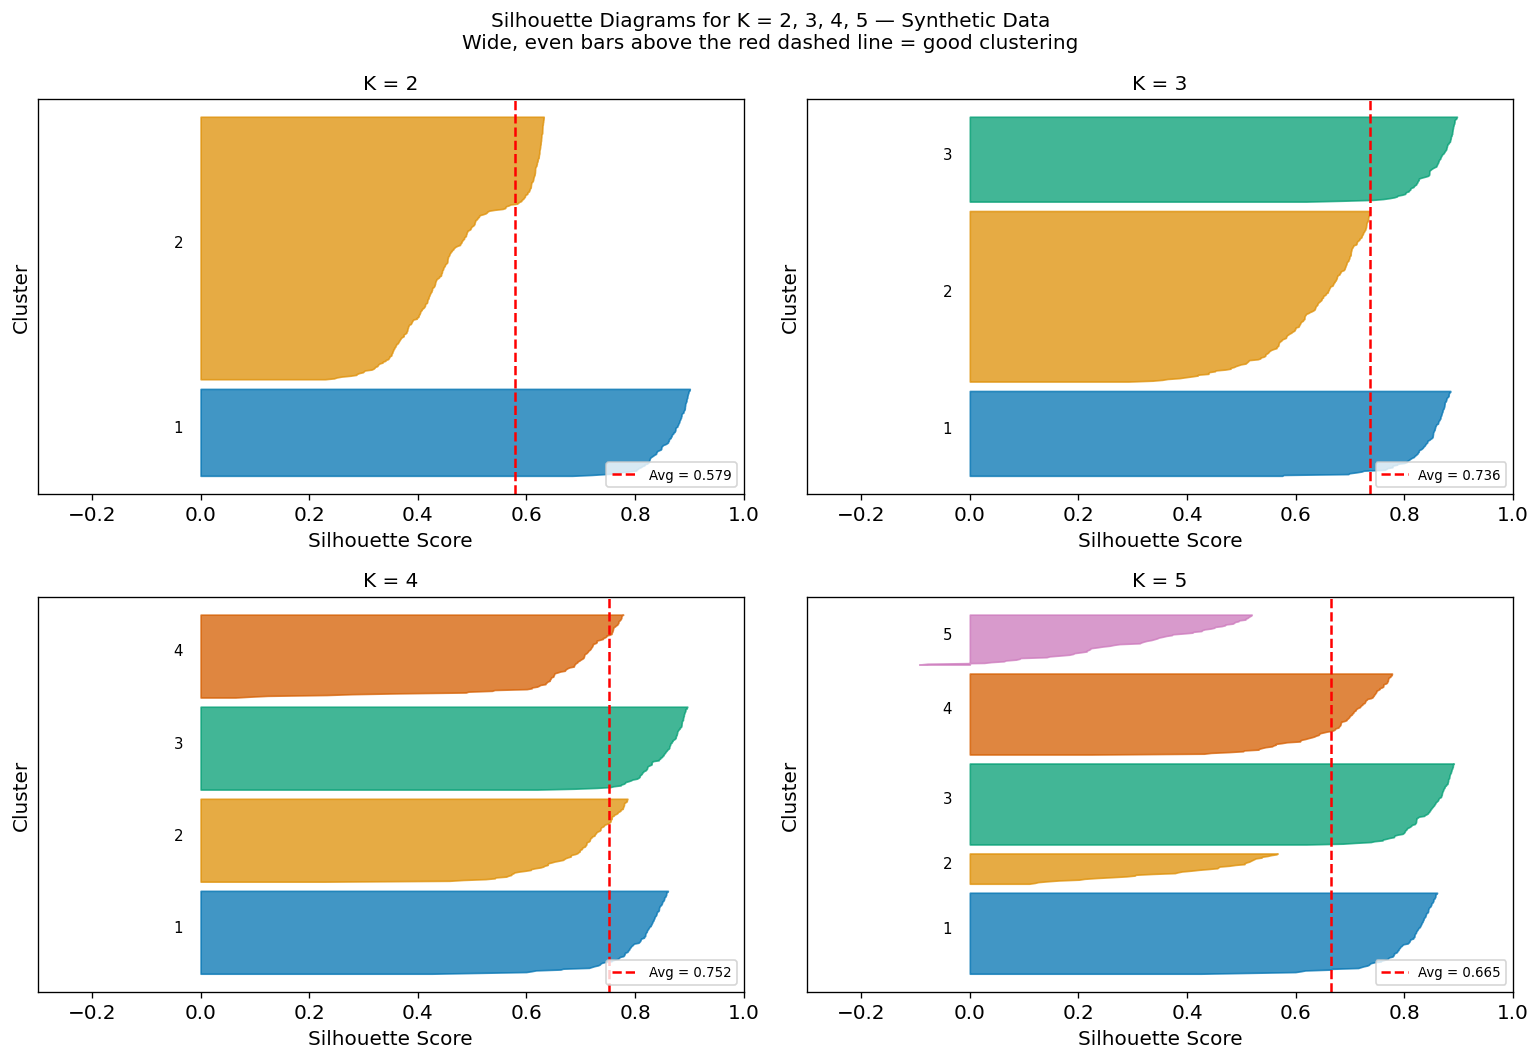

In [5]:
# ── Silhouette plots for K=2, 3, 4, 5 ────────────────────────────────────────
def plot_silhouette(X, k, ax, palette):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    avg_score = silhouette_score(X, labels)
    sample_scores = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(k):
        cluster_scores = np.sort(sample_scores[labels == i])
        size = cluster_scores.shape[0]
        y_upper = y_lower + size
        color = palette[i % len(palette)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores,
                         facecolor=color, edgecolor=color, alpha=0.75)
        ax.text(-0.05, y_lower + 0.5 * size, str(i + 1), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
               label=f'Avg = {avg_score:.3f}')
    ax.set_title(f'K = {k}', fontsize=12)
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.set_xlim(-0.3, 1)
    ax.legend(fontsize=8, loc='lower right')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, k in enumerate([2, 3, 4, 5]):
    plot_silhouette(X_syn, k, axes[idx], PALETTE)

fig.suptitle('Silhouette Diagrams for K = 2, 3, 4, 5 — Synthetic Data\n'
             'Wide, even bars above the red dashed line = good clustering',
             fontsize=12)
plt.tight_layout()
print('[Figure 4 Alt Text]: Four silhouette diagrams for K=2,3,4,5.'
      ' K=4 shows the widest, most uniform bars — all clusters score well above the average line.')
plt.savefig('fig4_silhouette_plots.png', bbox_inches='tight')
plt.show()

---
## 7. Part B — Real World Data: UCI Wine Dataset

Now we apply both methods to **real data**, where the true K is unknown. The Wine dataset contains 13 chemical measurements from 178 wine samples. This is much harder — the methods may not perfectly agree.

In [6]:
# ── Load Wine Dataset ─────────────────────────────────────────────────────────
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = wine.data
feature_names = wine.feature_names

# ── Scale the data — CRITICAL for K-Means ────────────────────────────────────
# K-Means uses Euclidean distance, so features on different scales bias results
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

print(f'Dataset shape: {X_wine.shape}')
print(f'Features: {feature_names}')
print(f'\nBefore scaling — Feature means: {X_wine.mean(axis=0).round(2)}')
print(f'After scaling  — Feature means: {X_wine_scaled.mean(axis=0).round(3)}')

df_wine = pd.DataFrame(X_wine_scaled, columns=feature_names)
df_wine.describe().round(2)

Dataset shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Before scaling — Feature means: [1.3000e+01 2.3400e+00 2.3700e+00 1.9490e+01 9.9740e+01 2.3000e+00
 2.0300e+00 3.6000e-01 1.5900e+00 5.0600e+00 9.6000e-01 2.6100e+00
 7.4689e+02]
After scaling  — Feature means: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.43,-1.43,-3.68,-2.67,-2.09,-2.11,-1.70,-1.87,-2.07,-1.63,-2.09,-1.90,-1.49
25%,-0.79,-0.66,-0.57,-0.69,-0.82,-0.89,-0.83,-0.74,-0.60,-0.80,-0.77,-0.95,-0.78
50%,0.06,-0.42,-0.02,0.00,-0.12,0.10,0.11,-0.18,-0.06,-0.16,0.03,0.24,-0.23
75%,0.84,0.67,0.70,0.60,0.51,0.81,0.85,0.61,0.63,0.49,0.71,0.79,0.76
max,2.26,3.11,3.16,3.15,4.37,2.54,3.06,2.40,3.49,3.44,3.30,1.96,2.97


[Figure 5 Alt Text]: Two boxplots comparing feature distributions before and after standard scaling. Before scaling shows very different ranges; after scaling all features are centred at 0 with similar spread.


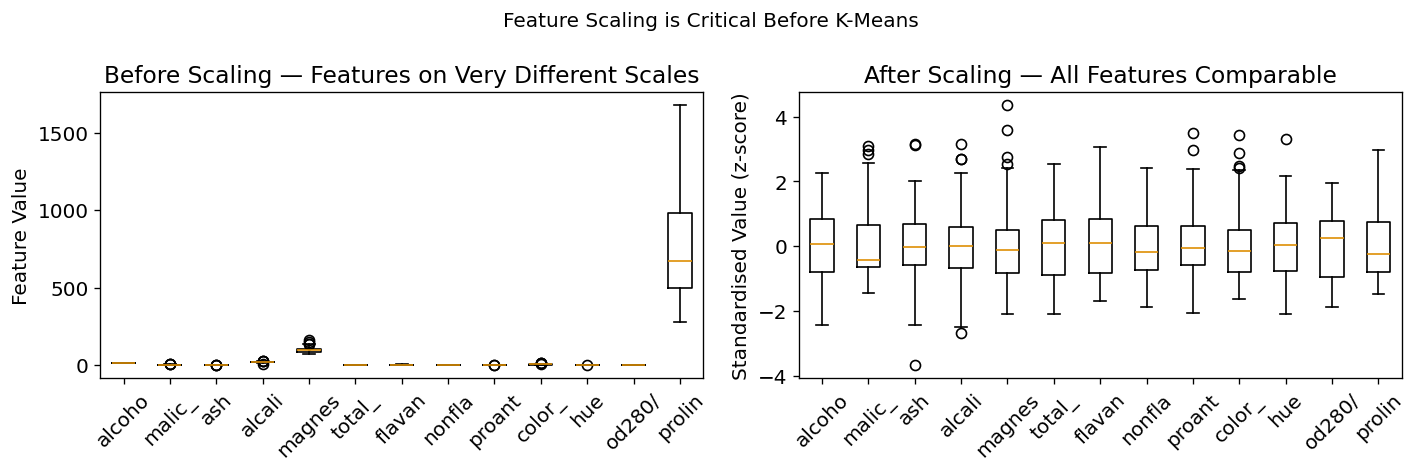

In [7]:
# ── Why Scaling Matters: A visual demonstration ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(X_wine, labels=[f[:6] for f in feature_names], vert=True)
axes[0].set_title('Before Scaling — Features on Very Different Scales')
axes[0].set_ylabel('Feature Value')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot(X_wine_scaled, labels=[f[:6] for f in feature_names], vert=True)
axes[1].set_title('After Scaling — All Features Comparable')
axes[1].set_ylabel('Standardised Value (z-score)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Scaling is Critical Before K-Means', fontsize=12)
plt.tight_layout()
print('[Figure 5 Alt Text]: Two boxplots comparing feature distributions before'
      ' and after standard scaling. Before scaling shows very different ranges;'
      ' after scaling all features are centred at 0 with similar spread.')
plt.savefig('fig5_scaling.png', bbox_inches='tight')
plt.show()


Best K by Silhouette (Wine): K=3
[Figure 6 Alt Text]: Two line plots for the wine dataset. Left shows the elbow curve; right shows silhouette scores peaking at K=3.


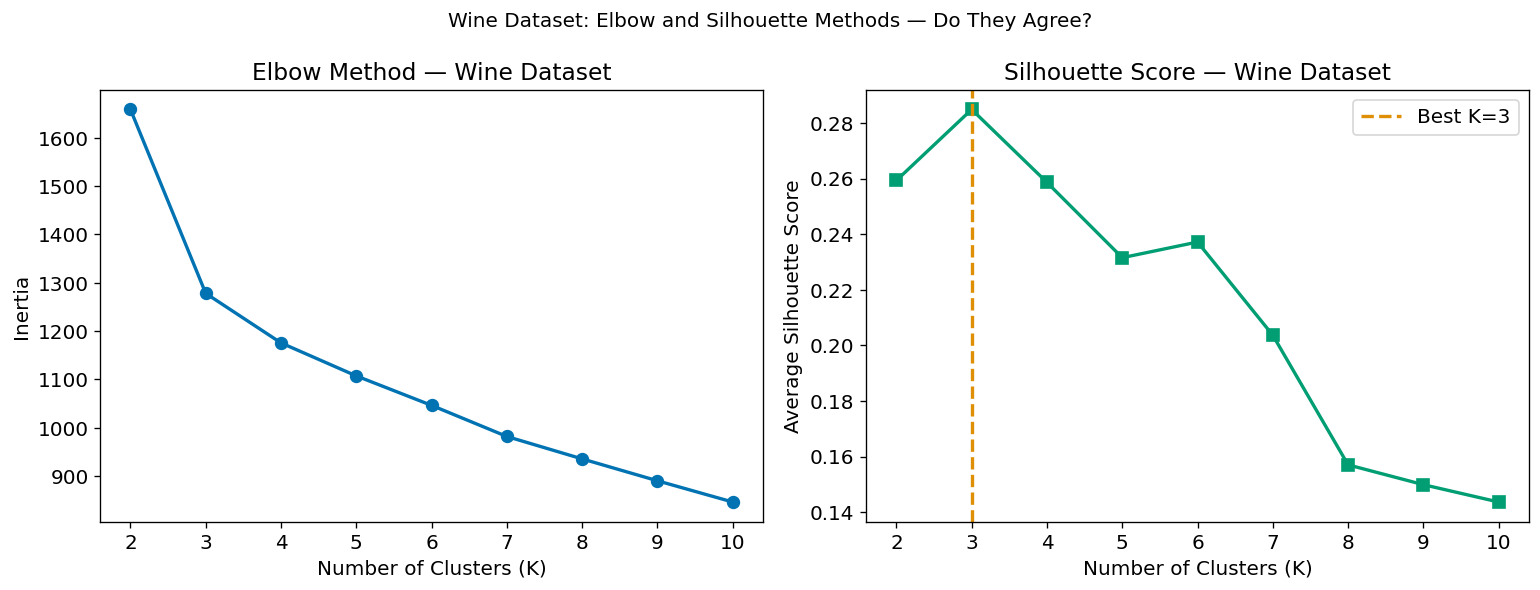

In [8]:
# ── Elbow + Silhouette for Wine Dataset ───────────────────────────────────────
K_range_wine = range(2, 11)
inertias_wine = []
sil_scores_wine = []

for k in K_range_wine:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_wine_scaled)
    inertias_wine.append(km.inertia_)
    sil_scores_wine.append(silhouette_score(X_wine_scaled, labels))

# ── Combined plot: Elbow + Silhouette side by side ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(list(K_range_wine), inertias_wine, 'o-', color=PALETTE[0],
             linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Wine Dataset')
axes[0].set_xticks(list(K_range_wine))

# Silhouette
best_k_wine = list(K_range_wine)[sil_scores_wine.index(max(sil_scores_wine))]
axes[1].plot(list(K_range_wine), sil_scores_wine, 's-', color=PALETTE[2],
             linewidth=2, markersize=7)
axes[1].axvline(x=best_k_wine, color=PALETTE[1], linestyle='--', linewidth=2,
                label=f'Best K={best_k_wine}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_title('Silhouette Score — Wine Dataset')
axes[1].set_xticks(list(K_range_wine))
axes[1].legend()

plt.suptitle('Wine Dataset: Elbow and Silhouette Methods — Do They Agree?', fontsize=12)
plt.tight_layout()
print(f'\nBest K by Silhouette (Wine): K={best_k_wine}')
print('[Figure 6 Alt Text]: Two line plots for the wine dataset.'
      ' Left shows the elbow curve; right shows silhouette scores peaking at K=3.')
plt.savefig('fig6_wine_evaluation.png', bbox_inches='tight')
plt.show()

---
## 8. Visualising the Final Clusters (PCA)

Since the Wine dataset has 13 features, we use **PCA** to reduce it to 2D for visualisation. This is for display only — the clustering was done on all 13 features.

Variance explained by 2 PCs: 55.4%
[Figure 7 Alt Text]: 2D scatter plot showing three coloured clusters of wine samples projected via PCA. Black X markers indicate centroids. Clusters are visibly separated.


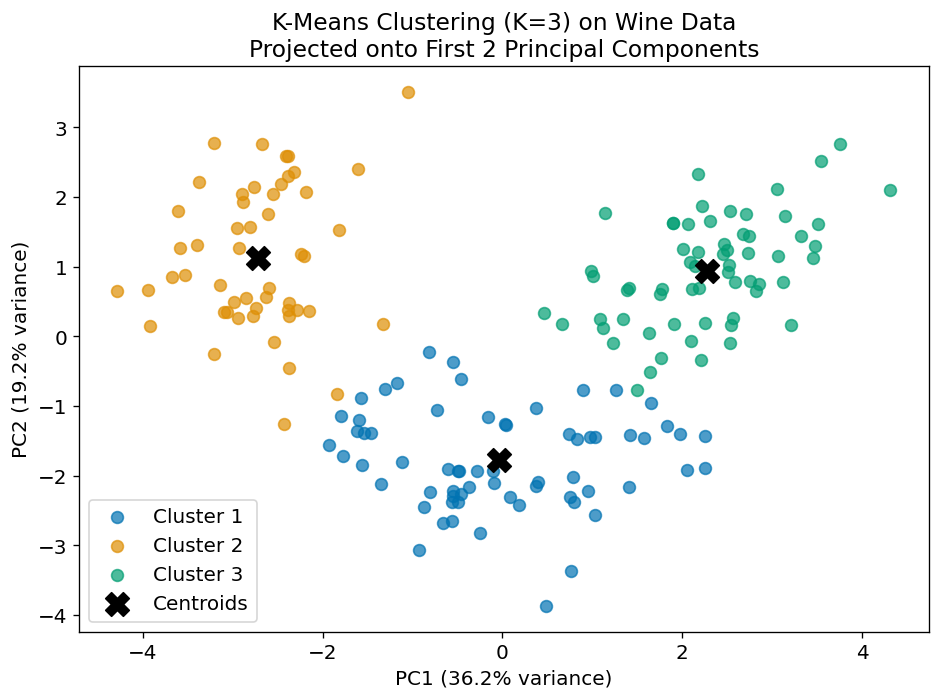

In [9]:
# ── PCA for 2D visualisation of final clustering ──────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

km_final = KMeans(n_clusters=best_k_wine, init='k-means++', n_init=20, random_state=RANDOM_STATE)
labels_final = km_final.fit_predict(X_wine_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(best_k_wine):
    mask = labels_final == k
    ax.scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
               label=f'Cluster {k+1}', alpha=0.7, s=50,
               color=PALETTE[k])

# Plot centroids (transformed to 2D)
centroids_2d = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           marker='X', s=200, color='black', label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clustering (K={best_k_wine}) on Wine Data\nProjected onto First 2 Principal Components')
ax.legend()

print(f'Variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')
print('[Figure 7 Alt Text]: 2D scatter plot showing three coloured clusters of wine samples'
      ' projected via PCA. Black X markers indicate centroids. Clusters are visibly separated.')
plt.savefig('fig7_wine_clusters_pca.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

---
## 9. When the Methods Disagree — A Demonstration

A key teaching point: the Elbow and Silhouette methods don't always agree. Below we demonstrate this with an **ambiguous dataset**.

[Figure 8 Alt Text]: Two plots for ambiguous data. The elbow curve on the left shows no clear bend. The silhouette plot on the right still shows a clear peak.


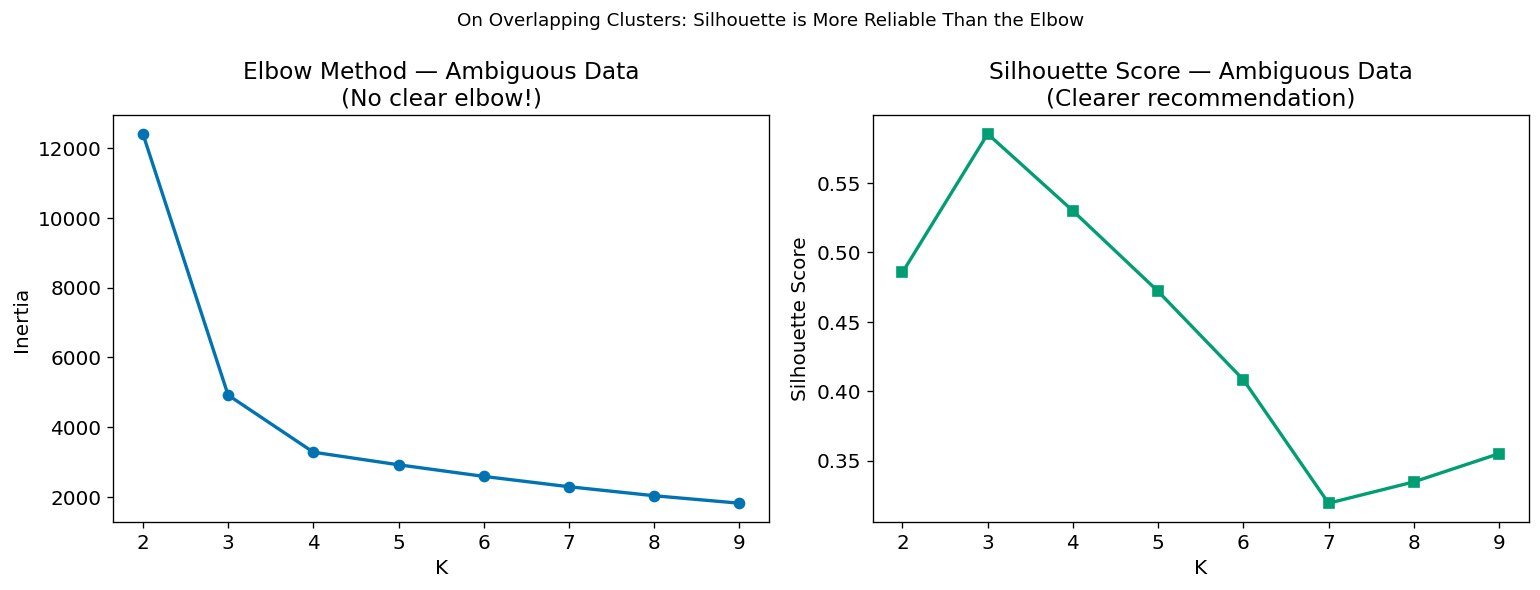

In [10]:
# ── Create ambiguous/overlapping dataset ──────────────────────────────────────
X_ambig, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=2.5,  # More overlap than before
    random_state=RANDOM_STATE
)

K_range_a = range(2, 10)
inertias_a, sil_scores_a = [], []

for k in K_range_a:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_ambig)
    inertias_a.append(km.inertia_)
    sil_scores_a.append(silhouette_score(X_ambig, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range_a), inertias_a, 'o-', color=PALETTE[0], linewidth=2)
axes[0].set_title('Elbow Method — Ambiguous Data\n(No clear elbow!)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range_a))

axes[1].plot(list(K_range_a), sil_scores_a, 's-', color=PALETTE[2], linewidth=2)
axes[1].set_title('Silhouette Score — Ambiguous Data\n(Clearer recommendation)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range_a))

plt.suptitle('On Overlapping Clusters: Silhouette is More Reliable Than the Elbow', fontsize=11)
plt.tight_layout()
print('[Figure 8 Alt Text]: Two plots for ambiguous data. The elbow curve on the left shows'
      ' no clear bend. The silhouette plot on the right still shows a clear peak.')
plt.savefig('fig8_disagreement.png', bbox_inches='tight')
plt.show()

---
## 10. Summary: Which Method Should You Use?

| Situation | Recommendation |
|-----------|----------------|
| Well-separated clusters | Both methods work — use Elbow for speed |
| Overlapping clusters | Prefer Silhouette Score |
| Large dataset (slow silhouette) | Use Elbow first, validate with Silhouette on a sample |
| Methods disagree | Use domain knowledge + try both K values |
| Always | **Always standardise your features before K-Means** |

### Key Takeaways
1. **Inertia always decreases** — the Elbow Method looks for diminishing returns
2. **Silhouette Score** gives a richer picture — it evaluates both cohesion AND separation
3. **Use both methods together** — they often agree, and when they don't, that itself is informative
4. **Feature scaling is not optional** — K-Means relies on Euclidean distance
5. **No method is perfect** — always validate with domain knowledge

In [11]:
# ── Final Summary Table ───────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Method': ['Elbow Method', 'Silhouette Score'],
    'What it measures': ['Inertia (within-cluster variance)', 'Cohesion vs Separation (-1 to +1)'],
    'Best K (Synthetic)': [TRUE_K, best_k],
    'Best K (Wine)': ['~3 (visual)', best_k_wine],
    'Speed': ['Fast', 'Slower (O(n²) per K)'],
    'Works for K=1?': ['Yes', 'No'],
})

print('=' * 70)
print('SUMMARY: Elbow Method vs Silhouette Score')
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)

SUMMARY: Elbow Method vs Silhouette Score
          Method                  What it measures  Best K (Synthetic) Best K (Wine)                Speed Works for K=1?
    Elbow Method Inertia (within-cluster variance)                   4   ~3 (visual)                 Fast            Yes
Silhouette Score Cohesion vs Separation (-1 to +1)                   4             3 Slower (O(n²) per K)             No


---
## References
Arthur, D. and Vassilvitskii, S. (2007) 'k-means++: The advantages of careful seeding', Proceedings of the 18th Annual ACM-SIAM Symposium on Discrete Algorithms, pp. 1027–1035

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, E. (2011) 'Scikit-learn: Machine Learning in Python', Journal of Machine Learning Research, 12, pp. 2825–2830. Available at: https://jmlr.org/papers/v12/pedregosa11a.html

Rousseeuw, P.J. (1987) 'Silhouettes: a graphical aid to the interpretation and validation of cluster analysis', Journal of Computational and Applied Mathematics, 20, pp. 53–65. Available at: https://doi.org/10.1016/0377-0427(87)90125-7

Scikit-learn developers (2024) Clustering. Available at: https://scikit-learn.org/stable/modules/clustering.html

Thorndike, R.L. (1953) 'Who belongs in the family?', Psychometrika, 18(4), pp. 267–276. Available at: https://doi.org/10.1007/BF02289263

UCI Machine Learning Repository Wine Dataset. Available at: https://archive.ics.uci.edu/ml/datasets/wine


---
**Licence:** MIT  
**GitHub:** [https://github.com/Easywiz/K-Means-Elbow-vs-Silhouette]